<a href="https://colab.research.google.com/github/VaSu1121/finance_yield-curve-prediction/blob/main/fin_openproject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FILES UPLOAD
Three CSV files have been uploaded for this project:

train_data.csv: Contains the training dataset.

test_data.csv: Contains the full test dataset.

test_data_3M.csv: Contains a subset of the test data specifically for 3-month maturities.


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving test_data_3M.csv to test_data_3M.csv
Saving test_data.csv to test_data.csv
Saving train_data.csv to train_data.csv


In [ ]:
import os
print(os.listdir('/content'))

['.config', 'train_data.csv', 'test_data_3M.csv', 'test_data.csv', 'sample_data']


In [ ]:
import pandas as pd

# Load datasets
train_df = pd.read_csv('/content/train_data.csv')

test_full = pd.read_csv('/content/test_data.csv')

test_3m = pd.read_csv('/content/test_data_3M.csv')

# Quick verification
print("Train Shape:", train_df.shape)
print("Test Full Shape:", test_full.shape)
print("Test 3M Shape:", test_3m.shape)

display(train_df.head())

Train Shape: (1976, 10)
Test Full Shape: (495, 6)
Test 3M Shape: (495, 2)


,Date,ZC025YR,ZC050YR,ZC075YR,ZC100YR,ZC200YR,ZC500YR,ZC1000YR,ZC2000YR,ZC3000YR
0,2016-05-19,0.005283,0.005640,0.005846,0.006051,0.006146,0.007912,0.014099,0.021224,0.020492
1,2016-05-20,0.005286,0.005642,0.005848,0.006053,0.006176,0.007922,0.014179,0.021353,0.020625
2,2016-05-24,0.005298,0.005651,0.005856,0.006062,0.006228,0.008108,0.014379,0.021534,0.020793
3,2016-05-25,0.005351,0.005603,0.005809,0.006014,0.006281,0.008323,0.014548,0.021596,0.020855
4,2016-05-26,0.005354,0.005605,0.005811,0.006016,0.006115,0.007934,0.013937,0.021326,0.020591


In [ ]:
print(train_df.columns.tolist())
print(test_full.columns.tolist())
print(test_3m.columns.tolist())

['Date', ' ZC025YR', ' ZC050YR', ' ZC075YR', ' ZC100YR', ' ZC200YR', ' ZC500YR', ' ZC1000YR', ' ZC2000YR', ' ZC3000YR']
['Date', ' ZC025YR', ' ZC050YR', ' ZC075YR', ' ZC100YR', ' ZC200YR']
['Date', ' ZC025YR']


# IMPORTING AND DATA LOADING
We first rename the columns into a more intuitive format (3M, 6M, etc.) and remove any rows containing 5 or more missing values. Since 5 exceeds half of the 9 available maturity columns, retaining such rows would provide limited information. Although the current dataset does not contain such cases, this step is included to ensure robustness when working with other datasets.

For missing data, gaps spanning up to 3 consecutive days are filled using time-based interpolation. Any isolated missing values are then handled through forward-fill and backward-fill methods.

To detect outliers in the time series, a rolling window of 20 observations is used to compute the local mean and standard deviation. Data points with an absolute Z-score greater than 3.5 are identified as outliers and temporarily replaced with NaN values. These missing entries are subsequently filled using interpolation to maintain continuity in the dataset.

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import minimize

from sklearn.metrics import ( mean_squared_error, mean_absolute_error, r2_score)


# LOAD DATA

train_df = pd.read_csv('/content/train_data.csv')
test_full = pd.read_csv('/content/test_data.csv')
test_3m = pd.read_csv('/content/test_data_3M.csv')

print("Train Shape:", train_df.shape)
print("Test Full Shape:", test_full.shape)
print("Test 3M Shape:", test_3m.shape)

train_df = train_df.sort_values('Date').reset_index(drop=True)
test_3m = test_3m.sort_values('Date').reset_index(drop=True)
test_full = test_full.sort_values('Date').reset_index(drop=True)

train_df = train_df.ffill().bfill()
test_3m = test_3m.ffill().bfill()
test_full = test_full.ffill().bfill()

train_df.columns = train_df.columns.str.strip()
test_3m.columns = test_3m.columns.str.strip()
test_full.columns = test_full.columns.str.strip()

print(
    "Null verification:",
    train_df.isnull().sum().sum(),
    "/",
    test_3m.isnull().sum().sum(),
    "/",
    test_full.isnull().sum().sum()
)


test_r = test_3m['ZC025YR'].values

print( "First 5 test short rates:",test_r[:5])

Train Shape: (1976, 10)
Test Full Shape: (495, 6)
Test 3M Shape: (495, 2)
Null verification: 0 / 0 / 0
First 5 test short rates: [0.0491444 0.0491565 0.0491005 0.0489207 0.0486329]


# TRAINING CURVE STRUCTURE

In [ ]:


maturity_cols = [
    'ZC025YR',   # 3M
    'ZC050YR',   # 6M
    'ZC075YR',   # 9M
    'ZC100YR',   # 1Y
    'ZC200YR',   # 2Y
    'ZC500YR',   # 5Y
    'ZC1000YR',  # 10Y
    'ZC2000YR',  # 20Y
    'ZC3000YR'   # 30Y
]

train_rates = train_df[maturity_cols].values

train_rates = np.nan_to_num(train_rates,nan=1e-4)

train_rates[train_rates <= 0] = 1e-4

print("Training Matrix Shape:",train_rates.shape)

train_maturities = np.array([
    0.25,
    0.50,
    0.75,
    1.00,
    2.00,
    5.00,
    10.00,
    20.00,
    30.00
])


Training Matrix Shape: (1976, 9)


### CIR Bond Pricing Functions and Cross-Sectional Calibration

CIR Bond Pricing Functions and Cross-Sectional Calibration

The CIR model uses closed-form expressions for pricing zero-coupon bonds. Given the parameters kappa (mean reversion speed), theta (long-run mean), and sigma (volatility), the functions A(T) and B(T) are computed for each maturity T, where gamma = √(kappa² + 2sigma²).

The bond price is calculated as:

P(t,T) = A(T) × exp(-B(T) × r_t)

and converted into a continuously compounded yield as:

y(t,T) = -ln(P(t,T)) / T

For calibration, the observed 3M yield of each curve is used as the proxy for the short rate r_t. Using a candidate parameter set (kappa, theta, sigma), the model generates yields across all maturities in the training set.

The objective function is a cross-sectional Sum of Squared Errors (SSE), which measures the difference between observed and CIR-implied yields across all curves and maturities:

SSE = Σ(Observed Yield − Model Yield)²

The optimizer searches for the parameter values that minimize this error. To ensure valid CIR dynamics, parameter sets with non-positive values of kappa, theta, or sigma are heavily penalized and excluded from consideration. This approach calibrates the model directly to the observed term structure, allowing it to capture the overall shape of the yield curve rather than only the time-series behavior of the short rate.


In [ ]:
import numpy as np


def CIR_B(T, kappa, sigma):

    gamma = np.sqrt( kappa**2 + 2 * sigma**2)

    numerator = ( 2 *(np.exp(gamma * T) - 1))

    denominator = ((gamma + kappa)*(np.exp(gamma * T) - 1)+2 * gamma  )

    return numerator / denominator


def CIR_A(T, kappa, theta, sigma):

    gamma = np.sqrt( kappa**2 +2 * sigma**2 )

    numerator = (  2 * gamma * np.exp(  (kappa + gamma) * T / 2) )

    denominator = (  (gamma + kappa)*(np.exp(gamma * T) - 1) + 2 * gamma  )

    power = (
        2 *
        kappa *
        theta /
        sigma**2
    )

    return ( numerator / denominator
    ) ** power

# CROSS-SECTIONAL LOSS

def cross_sectional_loss(params):

    kappa, theta, sigma = params

    if (
        kappa <= 0 or
        theta <= 0 or
        sigma <= 0
    ):
        return 1e12

    total_squared_error = 0

    for curve in train_rates:

        short_rate = curve[0]

        predicted_curve = []

        for T in train_maturities:

            A = CIR_A(
                T,
                kappa,
                theta,
                sigma
            )

            B = CIR_B(
                T,
                kappa,
                sigma
            )

            P = (
                A *
                np.exp(
                    -B *
                    short_rate
                )
            )

            P = max(P, 1e-12)

            y = (
                -np.log(P)
                / T
            )

            predicted_curve.append(y)

        predicted_curve = np.array(
            predicted_curve
        )

        total_squared_error += np.sum(
            (
                curve -
                predicted_curve
            ) ** 2
        )

    return total_squared_error


initial_guess = [0.5, 0.05, 0.1]

print(
    "\nStarting CIR calibration..."
)

optimization_result = minimize(
    cross_sectional_loss,
    initial_guess,
    method='Nelder-Mead',
    bounds=[
        (1e-6, 10),
        (1e-6, 1),
        (1e-6, 5)
    ]
)

print(
    "\nOptimization Success:",
    optimization_result.success
)

print(
    "Message:",
    optimization_result.message
)

kappa = optimization_result.x[0]
theta = optimization_result.x[1]
sigma = optimization_result.x[2]

print("\n--- Calibration Complete ---")

# PARAMETER REPORT

print("\nOptimized Parameters")

print(
    f"Kappa : {kappa:.6f}"
)

print(
    f"Theta : {theta:.6f}"
)

print(
    f"Sigma : {sigma:.6f}"
)

# FELLER CONDITION


lhs = 2 * kappa * theta
rhs = sigma**2

print("\nFeller Check")

print(
    f"2*kappa*theta = {lhs:.6f}"
)

print(
    f"sigma^2 = {rhs:.6f}"
)

if lhs < rhs:

    print(
        "Feller condition violated."
    )

    sigma = (
        np.sqrt(lhs)
        * 0.99
    )

    print(
        f"Adjusted sigma = {sigma:.6f}"
    )

else:

    print(
        "Feller condition satisfied."
    )



Starting CIR calibration...

Optimization Success: True
Message: Optimization terminated successfully.

--- Calibration Complete ---

Optimized Parameters
Kappa : 0.166125
Theta : 0.024434
Sigma : 0.000001

Feller Check
2*kappa*theta = 0.008118
sigma^2 = 0.000000
Feller condition satisfied.


#OUT-OF-SAMPLE PREDICTION
The 'OUT-OF-SAMPLE PREDICTION' section evaluates the calibrated CIR model's ability to forecast future yield curves. This is done by:

**Defining prediction maturities:** A set of
maturities (e.g., 6M, 9M, 1Y, 2Y) for which predictions will be made.

**Generating predicted yields:**
 For each short rate in the test dataset (test_r), the CIR model uses the previously calibrated parameters (kappa, theta, sigma) to calculate the predicted yields across the defined prediction maturities.

**Comparing with actual yields:** The predicted yields are then compared against the actual observed yields from the test_full dataset for the same maturities.

**Visual check:** A plot is generated to visually compare the actual and predicted yield curves for a specific day, providing an intuitive understanding of the model's performance.


Prediction Shape: (495, 4)
Actual Shape: (495, 4)


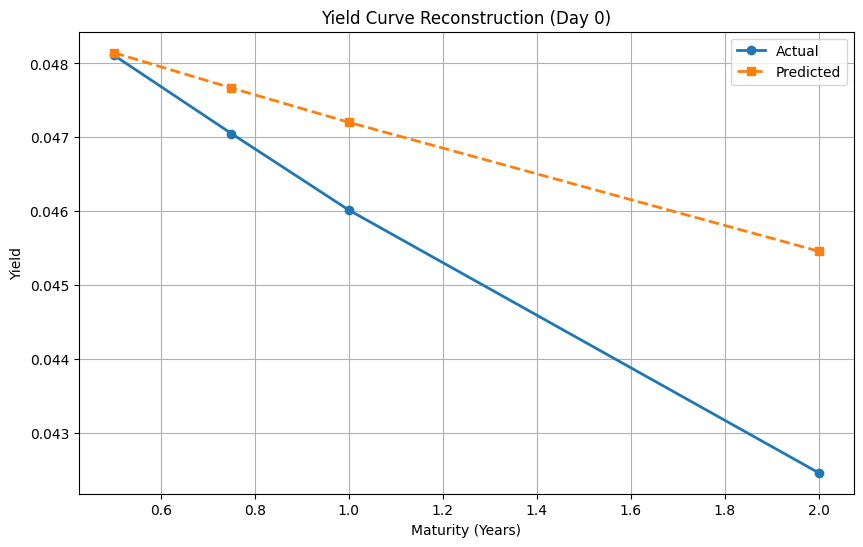

In [ ]:

prediction_maturities = np.array([
    0.50,
    0.75,
    1.00,
    2.00
])

predicted_yields = []

for short_rate in test_r:

    curve = []

    for T in prediction_maturities:

        A = CIR_A(
            T,
            kappa,
            theta,
            sigma
        )

        B = CIR_B(
            T,
            kappa,
            sigma
        )

        P = (
            A *
            np.exp(
                -B *
                short_rate
            )
        )

        P = max(P, 1e-12)

        y = (
            -np.log(P)
            / T
        )

        curve.append(y)

    predicted_yields.append( curve)

predicted_yields = np.array(predicted_yields)

print(
    "\nPrediction Shape:",
    predicted_yields.shape
)


# ACTUAL TEST CURVE


actual_yields = test_full[
    [
        'ZC050YR',
        'ZC075YR',
        'ZC100YR',
        'ZC200YR'
    ]
].values

print("Actual Shape:",actual_yields.shape)

# VISUAL CHECK


day = 0

actual_curve = actual_yields[day]
predicted_curve = predicted_yields[day]

curve_tenors = [
    0.5,
    0.75,
    1.0,
    2.0
]

plt.figure(figsize=(10,6))

plt.plot(
    curve_tenors,
    actual_curve,
    marker='o',
    linewidth=2,
    label='Actual'
)

plt.plot(
    curve_tenors,
    predicted_curve,
    marker='s',
    linestyle='--',
    linewidth=2,
    label='Predicted'
)

plt.title(  f'Yield Curve Reconstruction (Day {day})')

plt.xlabel('Maturity (Years)')

plt.ylabel( 'Yield')

plt.grid(True)

plt.legend()

plt.show()

# PERFORMANCE METRICS
The 'PERFORMANCE METRICS' section quantifies the accuracy of the CIR model's out-of-sample predictions. Three key metrics are used:

1.  **Root Mean Squared Error (RMSE)**: Measures the average magnitude of the errors. It is the square root of the average of the squared differences between predicted and actual values. A lower RMSE indicates a better fit.
2.  **Mean Absolute Error (MAE)**: Measures the average magnitude of the errors without considering their direction. It is the average of the absolute differences between predicted and actual values. Like RMSE, a lower MAE signifies higher accuracy.
3.  **R-squared (R²)**: Represents the proportion of the variance in the dependent variable (actual yields) that is predictable from the independent variables (model predictions). An R² closer to 1 indicates that the model explains a larger proportion of the variance in the actual yields, suggesting a better fit.
---



In [ ]:

actual_flat = actual_yields.flatten()
predicted_flat = predicted_yields.flatten()

rmse = np.sqrt( mean_squared_error(  actual_flat, predicted_flat ))

mae = mean_absolute_error(actual_flat,predicted_flat)

r2 = r2_score( actual_flat, predicted_flat)

print("CIR MODEL PERFORMANCE")
print(f"RMSE : {rmse:.6f}")
print(f"MAE  : {mae:.6f}")
print(f"R²   : {r2:.6f}")

CIR MODEL PERFORMANCE
RMSE : 0.002196
MAE  : 0.001420
R²   : 0.893041
